# Аналіз прямої мови

## Виокремлення фрагментів прямої мови

Кожен окремий діалог буде зберігатися в одному рядку `.txt` файлу. Тобто кожен рядок файлу - це окремий діалог.

In [1]:
import json
import os
import re

import requests
from dotenv import load_dotenv
from google import genai
from google.genai import types
from matplotlib import pyplot as plt

load_dotenv()

True

In [2]:
INPUT_FILE = "../lab01/Zabrodin_file_1.txt"
OUTPUT_FILE = "Zabrodin_file_7.txt"

pattern = re.compile(r"^—\s*.*$", flags=re.MULTILINE)

In [3]:
def extract_dialogue_blocks(text: str) -> list[dict]:
    lines = text.split("\n")
    results = []
    i = 0

    while i < len(lines):
        line = lines[i].strip()

        # Шукаємо рядок що закінчується на : (введення діалогу)
        intro_match = re.search(r"[^.!?]+:$", line)
        intro = line if intro_match else None

        # Якщо поточний рядок або наступний починається з —
        next_is_dialogue = (
                line.startswith("—") or
                (i + 1 < len(lines) and lines[i + 1].strip().startswith("—"))
        )

        if not (line.startswith("—") or (intro and next_is_dialogue)):
            i += 1
            continue

        # Збираємо всі репліки підряд
        start = i if line.startswith("—") else i + 1
        j = start
        dialogue_lines = []

        while j < len(lines) and lines[j].strip().startswith("—"):
            dialogue_lines.append(lines[j].strip())
            j += 1

        if dialogue_lines:
            results.append({
                "intro": intro,
                "dialogue": dialogue_lines,
            })
            i = j
        else:
            i += 1

    return results

In [4]:
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text = f.read()

dialogue_blocks = extract_dialogue_blocks(text)

print(f"Знайдено блоків діалогів: {len(dialogue_blocks)}")
for b in dialogue_blocks[:3]:
    print(f"\nВведення: {b['intro']}")
    for line in b["dialogue"]:
        print(f"  {line}")

Знайдено блоків діалогів: 326

Введення: None
  — Карпе! — промовив Лаврін. — А кого ти будеш оце сватать? Адже ж оце перед Семеном тебе батько, мабуть, оженить.
  — Посватаю, кого трапиться, — знехотя обізвався Карпо.
  — Сватай, Карпе, Палажку. Кращої од Палажки нема на всі Семигори.
  — То сватай, як тобі треба, — сказав Карпо.
  — Якби на мене, то я б сватав Палажку, — сказав Лаврін. — В Палажки брови, як шнурочки; моргне, ніби вогнем сипне. Одна брова варта вола, другій брові й ціни нема. А що вже гарна! Як намальована!
  — Коли в Палажки очі витрішкуваті, як у жаби, стан кривий, як у баби.
  — То сватай Хіврю. Хівря доладна, як писанка.
  — І вже доладна! Ходить так легенько, наче в ступі горох товче, а як говорить, то носом свистить.
  — То сватай Вівдю. Чим же Вівдя негарна? Говорить тонісінько, мов сопілка грає, а тиха, як ягниця.
  — Тиха, як телиця. Я люблю, щоб дівчина була трохи бриклива, щоб мала серце з перцем, — сказав Карпо.
  — То бери Химку. Ця як брикне, то й переки

In [5]:
END = r"[.!?]"
END_OR_COMMA = r"[,!?]"

rules = (
    # — Текст[END]
    re.compile(rf"^—\s*.+({END})$"),

    # — Текст[END_OR_COMMA] — слова автора[END]
    re.compile(rf"^—\s*.+({END_OR_COMMA})\s*—\s*[а-щьюяґєії].+({END})$"),

    # — Текст[END] — Слова автора[END]
    re.compile(rf"^—\s*.+({END})\s—\s[А-ЩЬЮЯҐЄІЇ].+({END})$"),

    # — Текст[END_OR_COMMA] — слова: — продовження[END]
    re.compile(rf"^—\s*.+({END_OR_COMMA})\s*—\s*[а-щьюяґєії].+:\s*—\s*.+({END})$"),
)

In [6]:
def validate_dialogue_blocks(blocks: list[dict]) -> None:
    valid = []
    invalid = []

    for block in blocks:
        block_valid = True
        for line in block["dialogue"]:
            if not any(rule.match(line) for rule in rules):
                block_valid = False
                break

        if block_valid:
            valid.append(block)
        else:
            invalid.append(block)

    print(f"Правильні блоки: {len(valid)}")
    print(f"Неправильні блоки: {len(invalid)}")

    if invalid:
        print("\nНеправильні блоки:")
        for i, b in enumerate(invalid[:3], 1):
            print(f"\n[{i}] Введення: {b['intro']}")
            for line in b["dialogue"]:
                marker = "+" if any(rule.match(line) for rule in rules) else "-"
                print(f"  {marker} {line}")


validate_dialogue_blocks(dialogue_blocks)

Правильні блоки: 325
Неправильні блоки: 1

Неправильні блоки:

[1] Введення: None
  + — Я тижня не пробула в свекрухи і вже сльозами облилася, — говорила Мелашка. — Якби Лаврін не оступався за мною, то вони б мене з'їли. А збоку через сіни живе Карпова Мотря, наче люта змія, не сприяє мені через свекруху. Заскубуть, заклюють вони мене, мамо, як лихі шуляки голубку.
  - — То ти, дочко, не потурай свекрусі. Адже Мотря не мовчить, то й ти не мовчи:
  + — Коли, мамо, кругом мене все чужі люди, чужий рід, чуже село. Я одна, як билина в полі, а вони всі на-мене, як вітер на билину.


Серед неправильно сформованих діалогів лише один. На мою думку, тут просто було допущена одруківна і замість ':' мала б бути '.'.

In [7]:
def fix_dialogue_blocks(blocks: list[dict]) -> list[dict]:
    for block in blocks:
        block["dialogue"] = [
            d[:-1] + '.' if d.endswith(':') else d
            for d in block["dialogue"]
        ]
    return blocks


dialogue_blocks = fix_dialogue_blocks(dialogue_blocks)
validate_dialogue_blocks(dialogue_blocks)

Правильні блоки: 326
Неправильні блоки: 0


In [8]:
SEPARATOR = "\n" + "*" * 40 + "\n"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for block in dialogue_blocks:
        if block["intro"]:
            f.write(block["intro"] + "\n")
        f.write("\n".join(block["dialogue"]))
        f.write(SEPARATOR)

## Звертання

In [9]:
PUNCT = r"[.!?,;:\-—]"
UA_WORD = r"\b[А-ЩЬЮЯҐЄІЇа-щьюяґєії][а-щьюяґєії'\-]*\b"

pattern = re.compile(rf"(?<={PUNCT})\s*({UA_WORD})\s*(?={PUNCT})", re.MULTILINE)

In [10]:
def find_vocatives(blocks: list[dict]) -> list[str]:
    words = []

    for block in blocks:
        for dialogue in block["dialogue"]:
            for m in pattern.finditer(dialogue):
                words.append(m.group(1))

    return list(set(words))


vocatives = find_vocatives(dialogue_blocks)
for v in sorted(vocatives):
    print(f"{v}")

Іване
Ідіть
Їжте
Їй-богу
А
Авжеж
Агапіте
Алипіє
Ану
Ат
Балаш
Балашова
Батюшко
Бач
Бе
Бери
Боже
Брешеш
Біжи
Вас
Верни
Ви
Видно
Вийду
Викупи
Водила
Вставай
Встаньте
Він
Гарна
Гвалт
Гей
Геть
Гляди
Глянь
Гм
Говори
Голубчику
Господи
Грицьку
Дай
Дайте
Дарма
Держи
Добривечір
Добридень
Дома
Дражнись
Еге
Ей
Ет
Жінко
Заскубуть
Звикай
Здається
Здоров
Йди
Йдіть
Кажи
Кажуть
Кайдаш
Кайдашенку
Кайдашихо
Карне
Карпе
Каша
Коли
Лаврін
Лавріне
Лаяли
Лучче
Мабуть
Мамо
Марино
Марусе
Марусю
Мелашка
Мелашко
Мені
Ми
Миколає
Може
Мокрино
Моргуля
Мотре
На
Навчай
Навіщо
Нате
Наш
Нащо
Недобрий
Нема
Нехай
Ну
Ні
О
Овва
Ого-го
Одривай
Одчепись
Одчепіться
Одчини
Ой
Ой-ой
Омелько
Омельку
Он
Опізнилась
Оступіться
От
Ото
Ох-ох
Ох-ох-ох
Оце
П'ятінко-матінко
Палажко
Палажку
Пам'ятай
Параска
Параско
Певно
Пересадиш
Перехрестися
Петре
Побачиш
Погана
Поганяй
Подивись
Покаляєш
Пом'яни
Помаж
Посватаю
Посилай
Правда
При
Прийду
Приходь
Проси
Прощай
Прощайте
Пху
Піди
Підсипай
Радуйся
Робили
Рятуй
Рятуйте
Сарандара
Сватай
Свят
Се


In [11]:
def analyze(words: list[str]) -> list[dict]:
    text = "\n".join(words)

    try:
        response = requests.post("http://localhost:3000/process", data={
            "data": text,
            "tokenizer": "",
            "tagger": "",
            "parser": "",
        })
        response.raise_for_status()
    except requests.exceptions.ConnectionError:
        raise

    result = []
    seen = set()
    for line in response.json()["result"].split("\n"):
        if not line or line.startswith("#"):
            continue

        fields = line.split("\t")

        if len(fields) < 10:
            continue

        word, lemma, upos, feats = fields[1], fields[2], fields[3], fields[5]

        if upos in ("NOUN", "PROPN") and "Animacy=Anim" in feats and ("Case=Nom" in feats or "Case=Voc" in feats):
            if lemma not in seen:
                seen.add(lemma)
                case = "Nom" if "Case=Nom" in feats else "Voc"
                result.append({"word": word, "lemma": lemma, "case": case})

    return result

In [12]:
results = analyze(vocatives)

OUTPUT_FILE = "Zabrodin_vocatives_full.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for r in results:
        f.write(f"{r['word']} {r['lemma']} {r['case']}\n")
        print(f"{r['word']} {r['lemma']} {r['case']}")

Марусе Марус Voc
П'ятінко П'ятінко Voc
матінко матінка Voc
Жінко Жінко Voc
матушко матушка Voc
Одчини одчина Nom
Балашова Балашов Nom
мати мати Nom
Дарма Дарма Nom
Бач Бач Nom
Суро Суро Nom
діти дитина Nom
дівчино дівчина Nom
Алипіє Алипія Nom
дівко дівка Voc
Карне Карне Voc
жінко жінка Voc
матінко матінко Nom
сердита сердита Nom
Марино Марино Nom
Батюшко Батюшко Nom
мамо мама Voc
Кайдашихо Кайдашиха Nom
княгине княгине Voc
Миколає Миколає Voc
Мелашка Мелашка Nom
Лаврін Лаврін Nom
Марусю Маруся Nom
коса коса Nom
Петре Петре Voc
Мамо Мамо Voc
Кайдаш Кайдаш Nom
Іване Іван Voc
Мелашко Мелашко Nom
Моргуля Моргуля Nom
ледащо ледащо Nom
Каша Каша Nom
Брешеш Брешеш Nom
Балаш Балаш Nom
Параска Параска Nom
марандара марандар Nom
Гвалт Гвалт Nom
Карпе Карпе Nom


Серед отриманих слів досі є неправильні.

In [13]:
def filter_vocatives(results: list[dict]) -> list[dict]:
    client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

    uploaded_file = client.files.upload(file=OUTPUT_FILE)

    prompt = (
        f"Відповідай лише JSON масивом слів без пояснень та Markdown.\n"
        f"З наступного списку слів залиш лише ті що є реальними звертаннями до людей або істот.\n"
        f"Звертанням може бути іменник у кличному відмінку (Voc) або називному (Nom) якщо він звертається до особи.\n"
        f"Прибери слова що не є звертаннями.\n"
        f"Повертай слова точно як вони є у файлі без змін.\n"
        f'Формат відповіді: ["слово1", "слово2", ...]'
    )

    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=[uploaded_file, prompt],
        config=types.GenerateContentConfig(
            thinking_config=types.ThinkingConfig(thinking_budget=1024)
        )
    )

    valid_words = set(json.loads(response.text))
    return [r for r in results if r["word"] in valid_words]


filtered = filter_vocatives(results)

OUTPUT_FILE = "Zabrodin_vocatives_filtered.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for r in filtered:
        f.write(f"{r['word']} {r['lemma']} {r['case']}\n")
        print(f"{r['word']} {r['lemma']} {r['case']}")

Марусе Марус Voc
П'ятінко П'ятінко Voc
матінко матінка Voc
Жінко Жінко Voc
матушко матушка Voc
Суро Суро Nom
діти дитина Nom
дівчино дівчина Nom
Алипіє Алипія Nom
дівко дівка Voc
Карне Карне Voc
жінко жінка Voc
матінко матінко Nom
Марино Марино Nom
Батюшко Батюшко Nom
мамо мама Voc
Кайдашихо Кайдашиха Nom
княгине княгине Voc
Миколає Миколає Voc
Марусю Маруся Nom
Петре Петре Voc
Мамо Мамо Voc
Мелашко Мелашко Nom
Карпе Карпе Nom


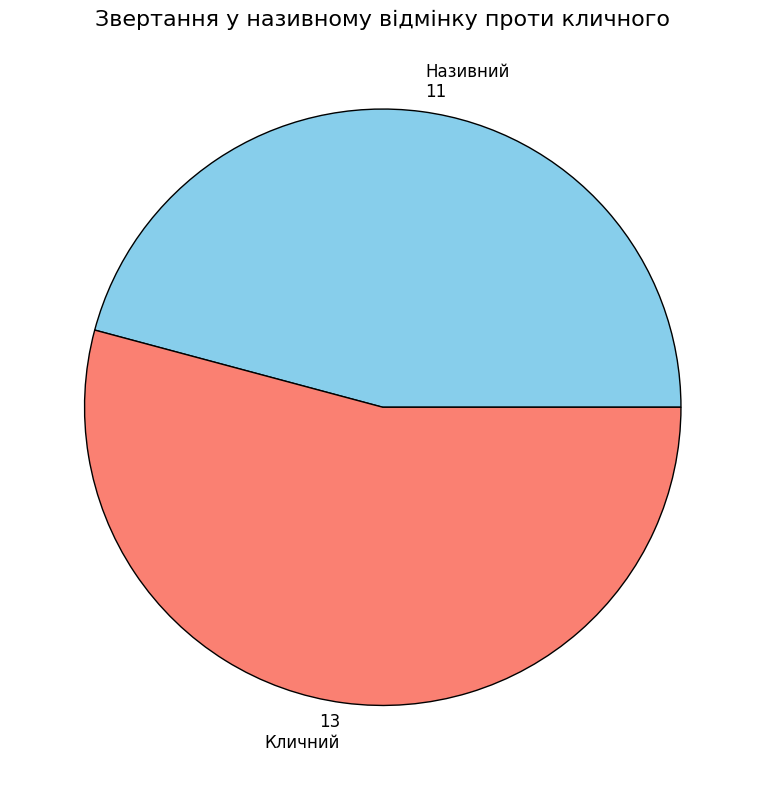

In [14]:
INPUT_FILE = "Zabrodin_vocatives_filtered.txt"
OUTPUT_IMAGE = "Zabrodin_vocatives_pie.png"

nom_count = sum(1 for r in filtered if r["case"] == "Nom")
voc_count = sum(1 for r in filtered if r["case"] == "Voc")

plt.figure(figsize=(8, 8))
plt.pie(
    [nom_count, voc_count],
    labels=[f"Називний\n{nom_count}", f"{voc_count}\nКличний"],
    colors=["skyblue", "salmon"],
    wedgeprops={"edgecolor": "black"},
    textprops={"fontsize": 12},
)

plt.title("Звертання у називному відмінку проти кличного", fontsize=16)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format="png", transparent=True, dpi=300)

plt.show()